In [1]:
# ========================
# ✅ 실험 환경 변수
# ========================

from datetime import datetime, timedelta

# 오늘 날짜
TODAY = datetime.today().strftime("%Y-%m-%d")

# 7년 전 날짜 계산
SEVEN_YEARS_AGO = (datetime.today() - timedelta(days=7*365)).strftime("%Y-%m-%d")

print(f"데이터 시작일: {SEVEN_YEARS_AGO}")
print(f"데이터 종료일: {TODAY}")

EXPERIMENT_NAME = "aapl_techindicators_v2"

SYMBOL = "AAPL"

# 자동 날짜
DATA_START_DATE = SEVEN_YEARS_AGO
DATA_END_DATE = TODAY

# Split 날짜 (약 5년 train, 2년 test 예제)
TRAIN_END_DATE = (datetime.today() - timedelta(days=2*365)).strftime("%Y-%m-%d")
TEST_START_DATE = (datetime.today() - timedelta(days=2*365 - 1)).strftime("%Y-%m-%d")

WINDOW_SIZE = 10

FEATURE_LIST = [
    "Close",
    "EMA20",
    "RSI14",
    "MACD_line",
    "MACD_signal",
    "OBV",
    "BBR",
    "Stoch_%K",
    "Stoch_%D"
]

SCALER_TYPE = "minmax"

LSTM_UNITS = 64
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 100
EARLYSTOPPING_PATIENCE = 5


데이터 시작일: 2018-07-04
데이터 종료일: 2025-07-02


In [2]:
import yfinance as yf
import pandas as pd

# 심볼 객체화
ticker = yf.Ticker(SYMBOL)

# 깨끗한 일간 데이터
df = ticker.history(start=DATA_START_DATE, end=DATA_END_DATE, interval="1d")
df = df.reset_index()

print(df.head())


                       Date       Open       High        Low      Close  \
0 2018-07-05 00:00:00-04:00  43.823336  44.095371  43.591518  43.856453   
1 2018-07-06 00:00:00-04:00  43.861174  44.573190  43.809133  44.464378   
2 2018-07-09 00:00:00-04:00  44.826297  45.105425  44.778988  45.081772   
3 2018-07-10 00:00:00-04:00  45.112525  45.247357  44.987150  45.027367   
4 2018-07-11 00:00:00-04:00  44.589752  44.892537  44.379223  44.443092   

     Volume  Dividends  Stock Splits  
0  66416800        0.0           0.0  
1  69940800        0.0           0.0  
2  79026400        0.0           0.0  
3  63756400        0.0           0.0  
4  75326000        0.0           0.0  


In [3]:
import pandas_ta as ta

df["EMA20"] = ta.ema(df["Close"], length=20)
df["RSI14"] = ta.rsi(df["Close"], length=14)
macd = ta.macd(df["Close"])
df["MACD_line"] = macd["MACD_12_26_9"]
df["MACD_signal"] = macd["MACDs_12_26_9"]
df["OBV"] = ta.obv(df["Close"], df["Volume"])
bbands = ta.bbands(df["Close"], length=20, std=2)
df["BBL"] = bbands["BBL_20_2.0"]
df["BBU"] = bbands["BBU_20_2.0"]
df["BBR"] = (df["Close"] - df["BBL"]) / (df["BBU"] - df["BBL"])
stoch = ta.stoch(df["High"], df["Low"], df["Close"])
df["Stoch_%K"] = stoch["STOCHk_14_3_3"]
df["Stoch_%D"] = stoch["STOCHd_14_3_3"]


# 확인
print(df[FEATURE_LIST].head(50))


        Close      EMA20      RSI14  MACD_line  MACD_signal           OBV  \
0   43.856453        NaN        NaN        NaN          NaN  6.641680e+07   
1   44.464378        NaN        NaN        NaN          NaN  1.363576e+08   
2   45.081772        NaN        NaN        NaN          NaN  2.153840e+08   
3   45.027367        NaN        NaN        NaN          NaN  1.516276e+08   
4   44.443092        NaN        NaN        NaN          NaN  7.630160e+07   
5   45.188232        NaN        NaN        NaN          NaN  1.484660e+08   
6   45.259193        NaN        NaN        NaN          NaN  1.985216e+08   
7   45.159847        NaN        NaN        NaN          NaN  1.383492e+08   
8   45.287590        NaN        NaN        NaN          NaN  2.004872e+08   
9   45.039192        NaN        NaN        NaN          NaN  1.349136e+08   
10  45.389297        NaN        NaN        NaN          NaN  2.160608e+08   
11  45.285210        NaN        NaN        NaN          NaN  1.333560e+08   

In [4]:
print(df.isnull().sum())
df = df.dropna().reset_index(drop=True)

from pandas import to_datetime
df["Date"] = to_datetime(df["Date"])
train_df = df[df["Date"] <= TRAIN_END_DATE].copy()
test_df = df[df["Date"] >= TEST_START_DATE].copy()
print(train_df.tail())
print(test_df.head())

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
Dividends        0
Stock Splits     0
EMA20           19
RSI14           14
MACD_line       25
MACD_signal     33
OBV              0
BBL             19
BBU             19
BBR             19
Stoch_%K        15
Stoch_%D        17
dtype: int64
                          Date        Open        High         Low  \
1219 2023-06-27 00:00:00-04:00  184.047268  186.522486  183.829448   
1220 2023-06-28 00:00:00-04:00  186.067055  188.017528  185.740340   
1221 2023-06-29 00:00:00-04:00  187.205648  188.185839  187.067036   
1222 2023-06-30 00:00:00-04:00  189.730365  192.552104  189.364023   
1223 2023-07-03 00:00:00-04:00  191.859062  191.958076  189.859082   

           Close    Volume  Dividends  Stock Splits       EMA20      RSI14  \
1219  186.195755  50730800        0.0           0.0  180.715727  69.672589   
1220  187.373978  51216800        0.0           0.0  181.349846  71.

In [5]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Feature 스케일러 (입력 피처 전처리용)
if SCALER_TYPE == "minmax":
    feature_scaler = MinMaxScaler()
else:
    feature_scaler = StandardScaler()
feature_scaler.fit(train_df[FEATURE_LIST])
train_scaled = feature_scaler.transform(train_df[FEATURE_LIST])
test_scaled = feature_scaler.transform(test_df[FEATURE_LIST])

# Close 전용 스케일러 (타겟 전처리용)
if SCALER_TYPE == "minmax":
    close_scaler = MinMaxScaler()
else:
    close_scaler = StandardScaler()
close_scaler.fit(train_df[['Close']])

MinMaxScaler()

In [6]:
import numpy as np

X_train, y_train = [], []
for i in range(WINDOW_SIZE, len(train_scaled)):
    X_train.append(train_scaled[i - WINDOW_SIZE:i])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_test, y_test = [], []
for i in range(WINDOW_SIZE, len(test_scaled)):
    X_test.append(test_scaled[i - WINDOW_SIZE:i])
    y_test.append(test_scaled[i, 0])
X_test, y_test = np.array(X_test), np.array(y_test)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(LSTM(LSTM_UNITS, input_shape=(WINDOW_SIZE, len(FEATURE_LIST))))
model.add(Dropout(DROPOUT_RATE))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mse')
model.summary()

2025-07-02 12:47:10.725900: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-02 12:47:10.766212: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-02 12:47:12.167162: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-07-02 12:47:14.554480: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-02 12:47:14.634

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                18944     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 19,009
Trainable params: 19,009
Non-trainable params: 0
_________________________________________________________________


In [8]:
from tensorflow.keras.callbacks import EarlyStopping

earlystop = EarlyStopping(patience=EARLYSTOPPING_PATIENCE, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[earlystop],
    shuffle=False,  
    verbose=2
)

Epoch 1/100


2025-07-02 12:47:18.503342: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-02 12:47:18.505669: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-02 12:47:18.508240: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

18/18 - 2s - loss: 0.0141 - val_loss: 0.0308 - 2s/epoch - 124ms/step
Epoch 2/100


2025-07-02 12:47:20.463709: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-02 12:47:20.465520: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-02 12:47:20.468194: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

18/18 - 0s - loss: 0.1063 - val_loss: 0.0026 - 132ms/epoch - 7ms/step
Epoch 3/100
18/18 - 0s - loss: 0.0422 - val_loss: 0.0653 - 124ms/epoch - 7ms/step
Epoch 4/100
18/18 - 0s - loss: 0.0183 - val_loss: 0.0014 - 139ms/epoch - 8ms/step
Epoch 5/100
18/18 - 0s - loss: 0.0186 - val_loss: 0.0086 - 143ms/epoch - 8ms/step
Epoch 6/100
18/18 - 0s - loss: 0.0076 - val_loss: 0.0036 - 138ms/epoch - 8ms/step
Epoch 7/100
18/18 - 0s - loss: 0.0069 - val_loss: 0.0015 - 155ms/epoch - 9ms/step
Epoch 8/100
18/18 - 0s - loss: 0.0065 - val_loss: 0.0015 - 139ms/epoch - 8ms/step
Epoch 9/100
18/18 - 0s - loss: 0.0052 - val_loss: 0.0013 - 167ms/epoch - 9ms/step
Epoch 10/100
18/18 - 0s - loss: 0.0054 - val_loss: 0.0011 - 178ms/epoch - 10ms/step
Epoch 11/100
18/18 - 0s - loss: 0.0049 - val_loss: 9.3898e-04 - 133ms/epoch - 7ms/step
Epoch 12/100
18/18 - 0s - loss: 0.0042 - val_loss: 5.1002e-04 - 139ms/epoch - 8ms/step
Epoch 13/100
18/18 - 0s - loss: 0.0042 - val_loss: 9.0035e-04 - 140ms/epoch - 8ms/step
Epoch 14/10

In [9]:
pred_scaled = model.predict(X_test).flatten()
print("📌 Scaled 예측 샘플:", pred_scaled[:5])
print("📌 Scaled 실제 샘플:", y_test[:5])


16/16 [==============================] - 0s 5ms/step
📌 Scaled 예측 샘플: [0.99931806 1.0097625  1.012457   1.0092453  1.0055271 ]
📌 Scaled 실제 샘플: [1.00707315 0.99474207 0.98729357 0.99236377 0.99780914]


2025-07-02 12:47:24.437071: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-02 12:47:24.438413: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-02 12:47:24.439535: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [10]:
predicted_prices = close_scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
actual_prices = close_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)
r2 = r2_score(actual_prices, predicted_prices)

print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ R²: {r2:.4f}")


✅ RMSE: 5.7661
✅ MAE: 4.1105
✅ R²: 0.9431


In [25]:
# %%
# ✅ 모델 저장
model.save('lstm_close_predictor_v1.h5')
print("✅ 모델이 'lstm_close_predictor_v1.h5' 로 저장되었습니다.")


✅ 모델이 'lstm_close_predictor_v1.h5' 로 저장되었습니다.


✅ Residual 샘플: [ 1.22668457 -2.37588501 -3.98027039 -2.67025757 -1.22080994]


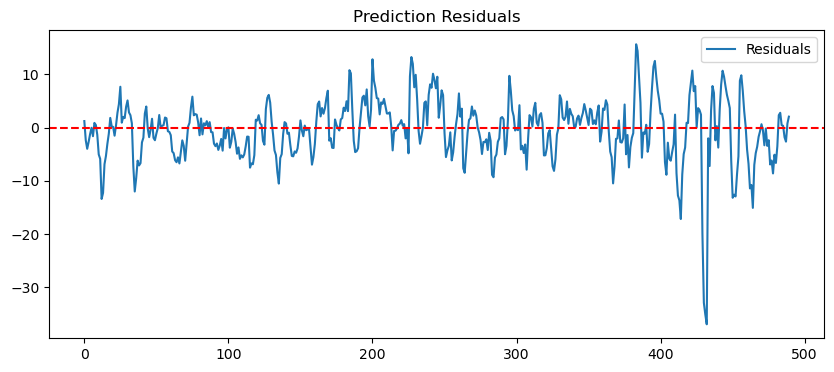

In [12]:
residuals = actual_prices - predicted_prices
print("✅ Residual 샘플:", residuals[:5])

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Prediction Residuals')
plt.legend()
plt.show()


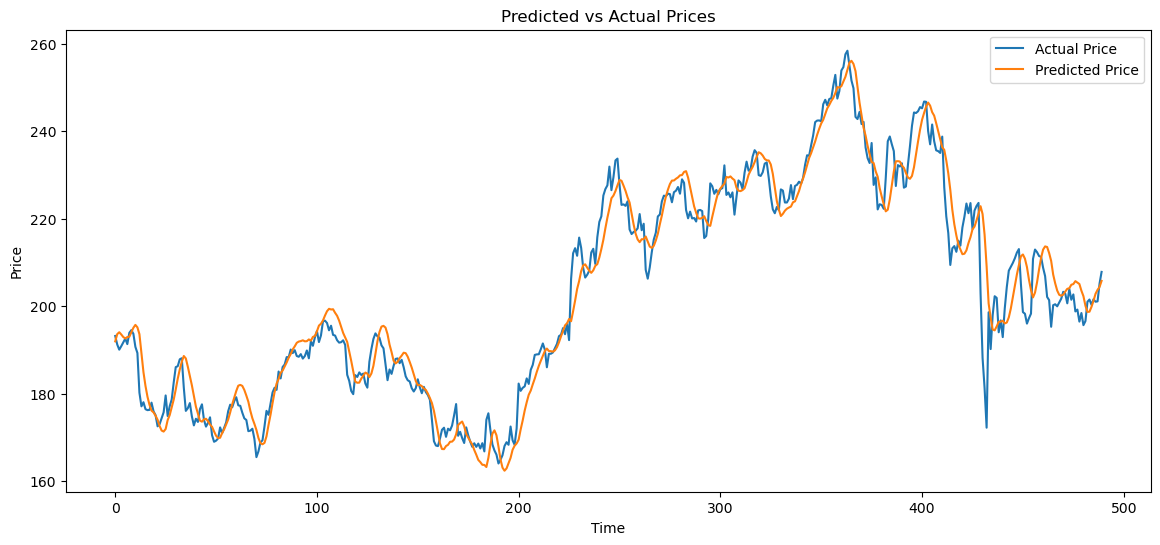

In [13]:
plt.figure(figsize=(14,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title('Predicted vs Actual Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


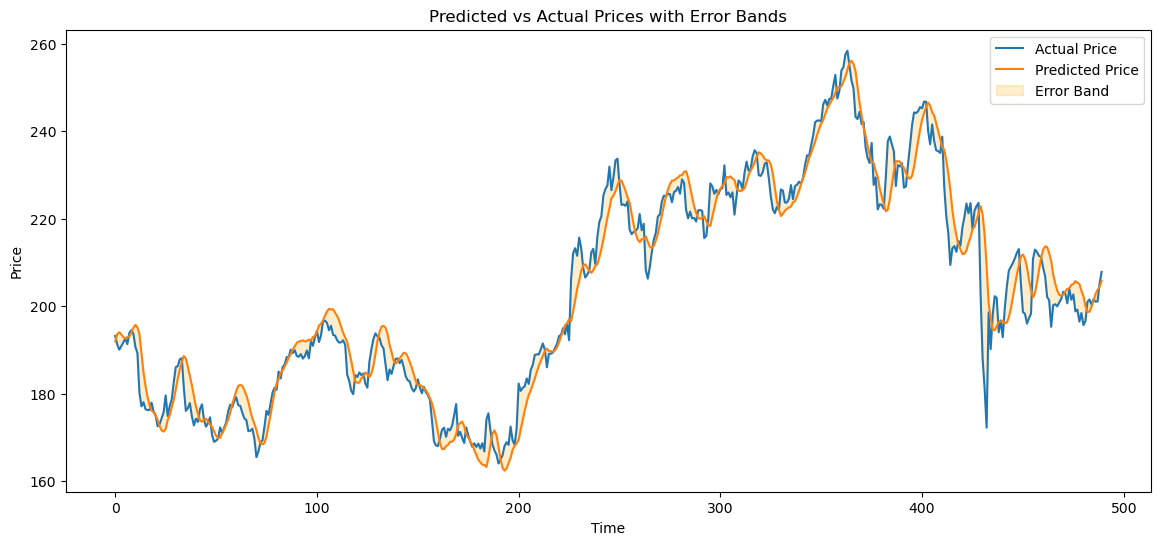

In [14]:
plt.figure(figsize=(14,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.fill_between(range(len(actual_prices)), actual_prices, predicted_prices, color='orange', alpha=0.2, label='Error Band')
plt.title('Predicted vs Actual Prices with Error Bands')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [15]:
# Dropna 후의 깨끗한 날짜열
df = df.dropna().reset_index(drop=True)
df["Date"] = pd.to_datetime(df["Date"])

# ✅ 정확한 Split
train_df = df[df["Date"] < TEST_START_DATE].copy()
test_df = df[df["Date"] >= TEST_START_DATE].copy()

print(f"Train 기간: {train_df['Date'].min()} ~ {train_df['Date'].max()}")
print(f"Test 기간: {test_df['Date'].min()} ~ {test_df['Date'].max()}")

# ✅ Feature 스케일러
feature_scaler = MinMaxScaler()
feature_scaler.fit(train_df[FEATURE_LIST])
train_scaled = feature_scaler.transform(train_df[FEATURE_LIST])
test_scaled = feature_scaler.transform(test_df[FEATURE_LIST])

# ✅ Close 스케일러
close_scaler = MinMaxScaler()
close_scaler.fit(train_df[['Close']])


Train 기간: 2018-08-21 00:00:00-04:00 ~ 2023-07-03 00:00:00-04:00
Test 기간: 2023-07-05 00:00:00-04:00 ~ 2025-07-01 00:00:00-04:00


MinMaxScaler()

In [16]:
X_train, y_train = [], []
for i in range(WINDOW_SIZE, len(train_scaled)):
    X_train.append(train_scaled[i - WINDOW_SIZE:i])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_test, y_test = [], []
for i in range(WINDOW_SIZE, len(test_scaled)):
    X_test.append(test_scaled[i - WINDOW_SIZE:i])
    y_test.append(test_scaled[i, 0])
X_test, y_test = np.array(X_test), np.array(y_test)


In [17]:
pred_scaled_train = model.predict(X_train).flatten()
train_predicted = close_scaler.inverse_transform(pred_scaled_train.reshape(-1,1)).flatten()
train_actual = close_scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

pred_scaled_test = model.predict(X_test).flatten()
test_predicted = close_scaler.inverse_transform(pred_scaled_test.reshape(-1,1)).flatten()
test_actual = close_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()


16/16 [==============================] - 0s 5ms/step


In [18]:
train_dates = train_df["Date"].values[WINDOW_SIZE:]
test_dates = test_df["Date"].values[WINDOW_SIZE:]


In [19]:
train_residual = train_actual - train_predicted
test_residual = test_actual - test_predicted


In [20]:
split_date = test_dates[0]


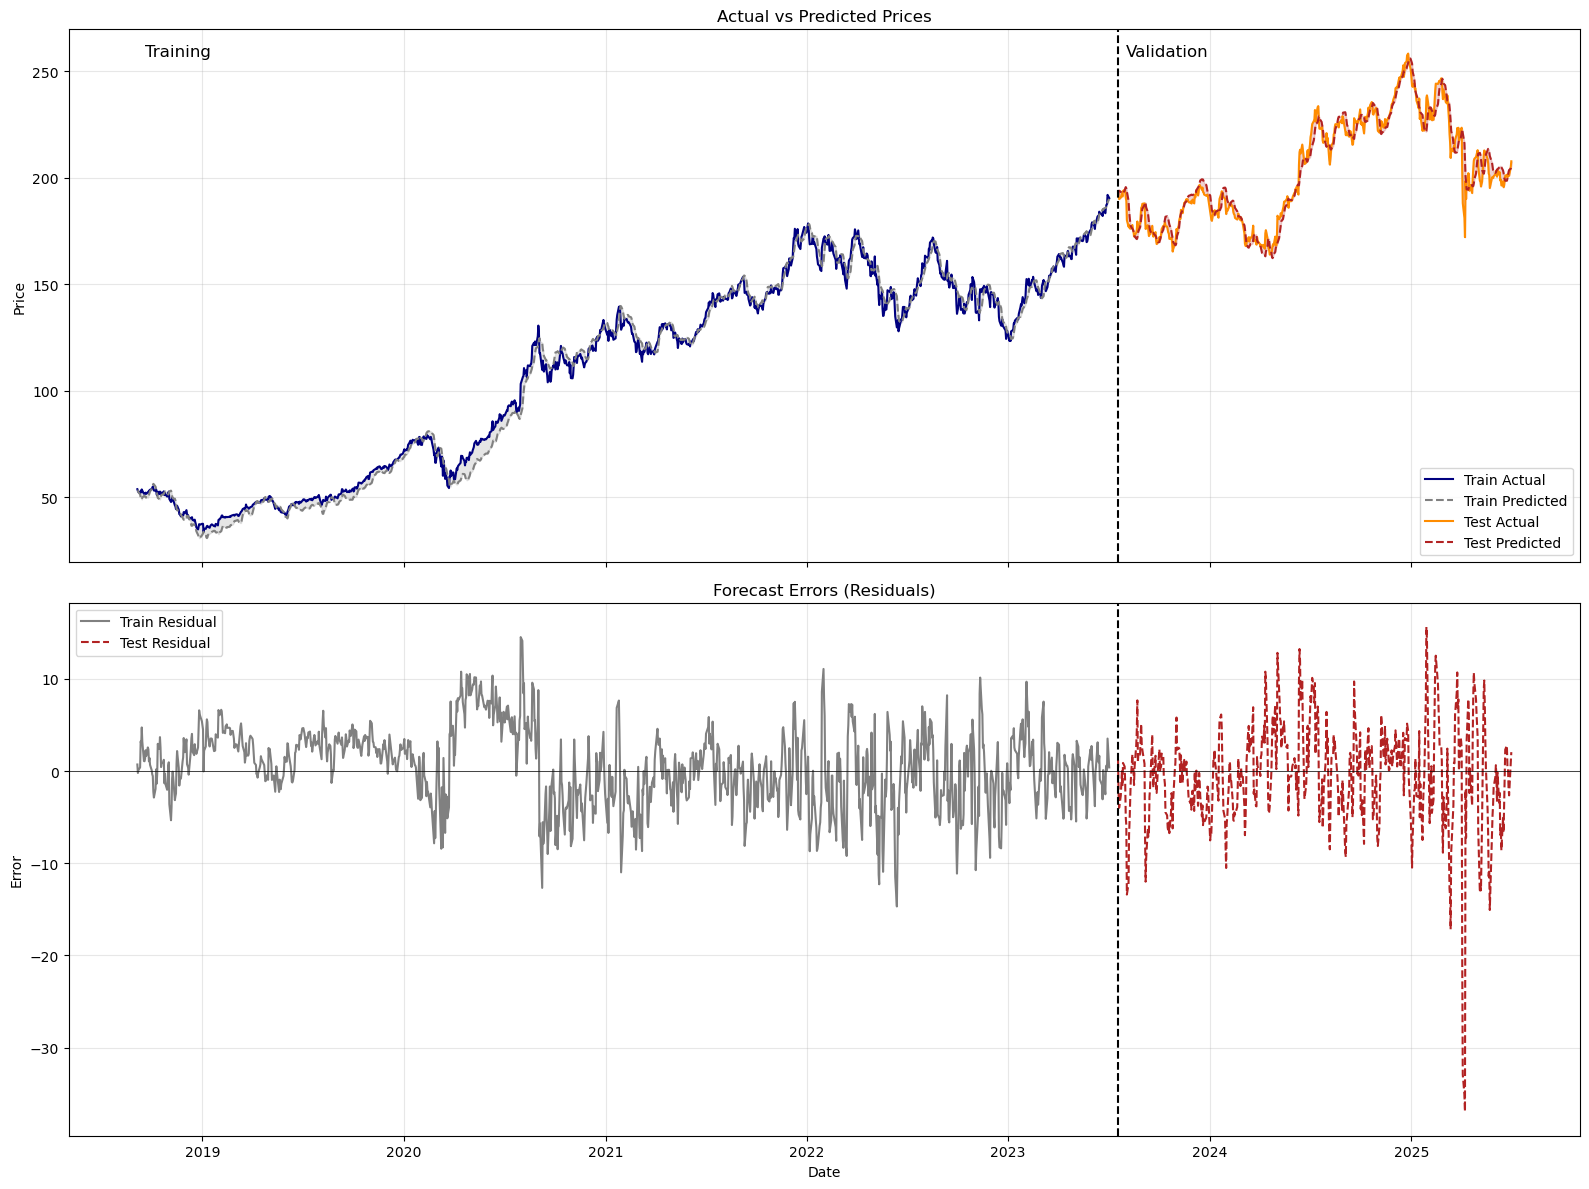

In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# ====== ① Actual vs Predicted ======
ax1.plot(train_dates, train_actual, label='Train Actual', color='navy')
ax1.plot(train_dates, train_predicted, label='Train Predicted', color='gray', linestyle='--')
ax1.fill_between(train_dates, train_actual, train_predicted, color='gray', alpha=0.2)

ax1.plot(test_dates, test_actual, label='Test Actual', color='darkorange')
ax1.plot(test_dates, test_predicted, label='Test Predicted', color='firebrick', linestyle='--')
ax1.fill_between(test_dates, test_actual, test_predicted, color='firebrick', alpha=0.2)

ax1.axvline(split_date, color='black', linestyle='--', linewidth=1.5)
ax1.set_title('Actual vs Predicted Prices')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(alpha=0.3)

# Training / Validation Label
ypos = ax1.get_ylim()[0] + 0.95 * (ax1.get_ylim()[1] - ax1.get_ylim()[0])
ax1.text(train_dates[10], ypos, 'Training', fontsize=12)
ax1.text(test_dates[10], ypos, 'Validation', fontsize=12)


# ====== ② Forecast Errors ======
ax2.plot(train_dates, train_residual, color='gray', label='Train Residual')
ax2.plot(test_dates, test_residual, color='firebrick', linestyle='--', label='Test Residual')

ax2.axvline(split_date, color='black', linestyle='--', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Forecast Errors (Residuals)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


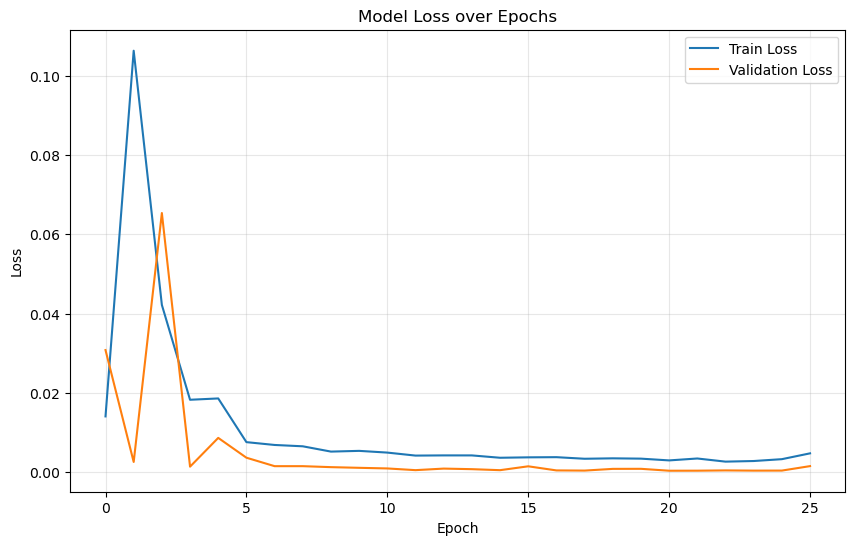

In [22]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

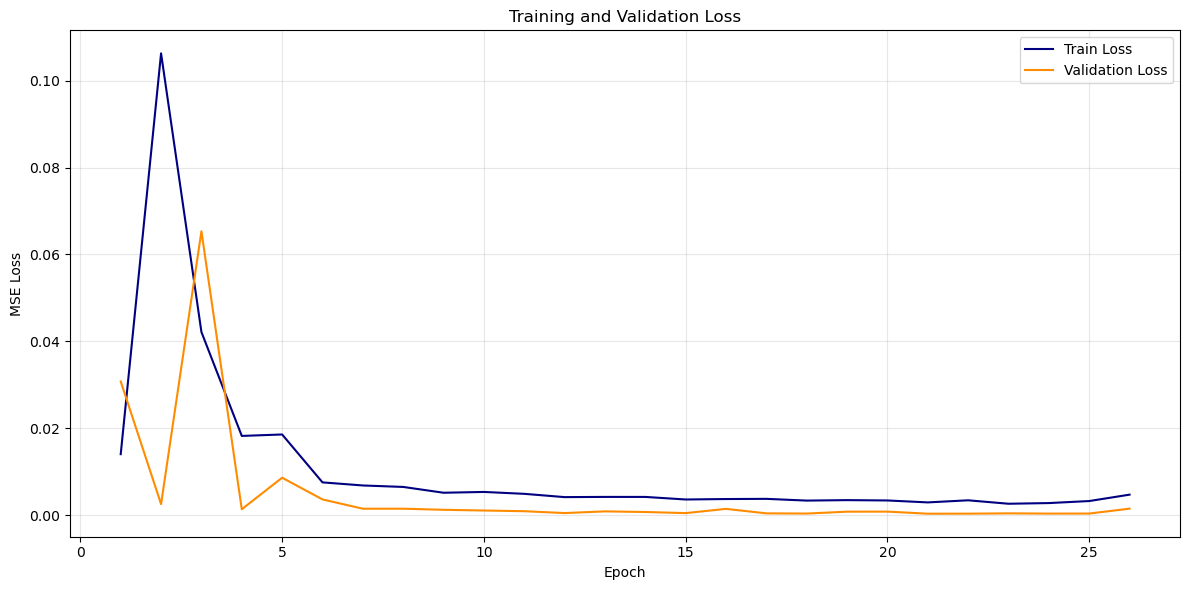

In [23]:
plt.figure(figsize=(12,6))
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'], label='Train Loss', color='navy')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)

# Optional: 로그스케일
# plt.yscale('log')

plt.tight_layout()
plt.show()


✅ Backtest 시작
✅ 실제 수익률 샘플: [-0.01009746 -0.00616151  0.00422015  0.00451337  0.00454507]
✅ 예측 포지션 샘플: [ 1.  1. -1. -1. -1.]
✅ 전략 수익률 샘플: [-0.01009746 -0.00616151 -0.00422015 -0.00451337 -0.00454507]


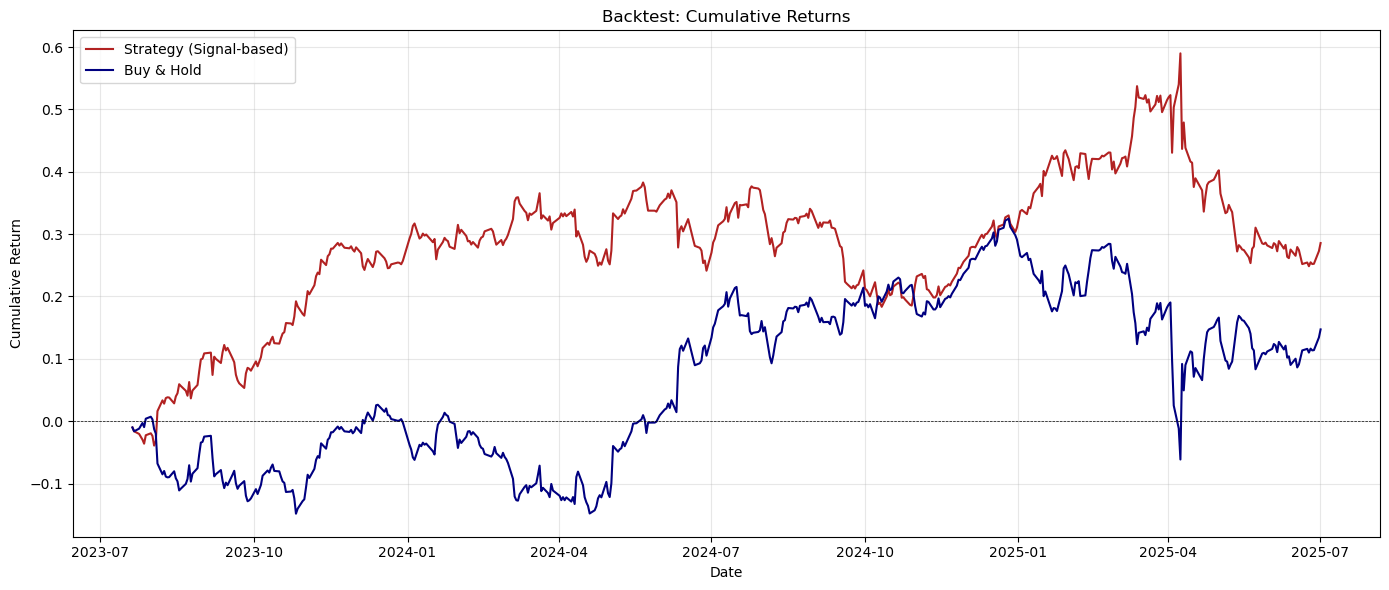

✅ Strategy Total Return: 0.2857
✅ Buy & Hold Total Return: 0.1472


In [24]:
import numpy as np
import matplotlib.pyplot as plt

print("✅ Backtest 시작")

# ① 실제 다음날 수익률 계산
actual_return = (test_actual[1:] / test_actual[:-1]) - 1
print("✅ 실제 수익률 샘플:", actual_return[:5])

# ② 예측 변화 → 포지션 결정
# 예측값이 상승 → long(+1)
# 예측값이 하락 → short(-1)
pred_diff = test_predicted[1:] - test_predicted[:-1]
pred_position = np.sign(pred_diff)
print("✅ 예측 포지션 샘플:", pred_position[:5])

# ③ 전략 수익률 계산
strategy_return = pred_position * actual_return
print("✅ 전략 수익률 샘플:", strategy_return[:5])

# ④ 누적 수익률
cum_strategy_return = np.cumsum(strategy_return)
cum_buyhold_return = np.cumsum(actual_return)

# ⑤ 날짜 맞추기 (첫날은 비교 못하니까 잘라주기)
bt_dates = test_dates[1:]

# ⑥ 시각화
plt.figure(figsize=(14,6))
plt.plot(bt_dates, cum_strategy_return, label='Strategy (Signal-based)', color='firebrick')
plt.plot(bt_dates, cum_buyhold_return, label='Buy & Hold', color='navy')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Backtest: Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ⑦ 최종 결과 요약
total_strategy = cum_strategy_return[-1]
total_buyhold = cum_buyhold_return[-1]
print(f"✅ Strategy Total Return: {total_strategy:.4f}")
print(f"✅ Buy & Hold Total Return: {total_buyhold:.4f}")





## ✅ 1️⃣ 단일 검증 구간 백테스트

- **구간**: 최근 2년 (테스트셋)
- **방법**: t+1 종가 예측 → 다음날 방향성으로 매수/매도 포지션 생성
- **누적 수익률 곡선**:
  - Strategy가 Buy&Hold보다 누적 수익률이 높게 나오는 구간이 많았음
  - 최종적으로 Strategy Total Return > Buy&Hold
- **의미**:
  - 최근 시장(검증 구간)은 강한 추세(Drift)가 유지되었을 가능성
  - Drift를 복사하는 LSTM 전략이 잘 맞음
  - Noise가 상대적으로 적고 Drift가 주요 예측신호가 됨

✅ **결론**:
> Drift 복사 기반 전략이 “최근 2년의 추세 환경”에서는 잘 작동했다.


✅ 랜덤 5일 구간을 5000회 샘플링합니다...
✅ 샘플 수: 5000
✅ 평균 Strategy Return: 0.0032
✅ 평균 Buy&Hold Return: 0.0005
✅ 평균 차이 (Strategy - Buy&Hold): 0.0026


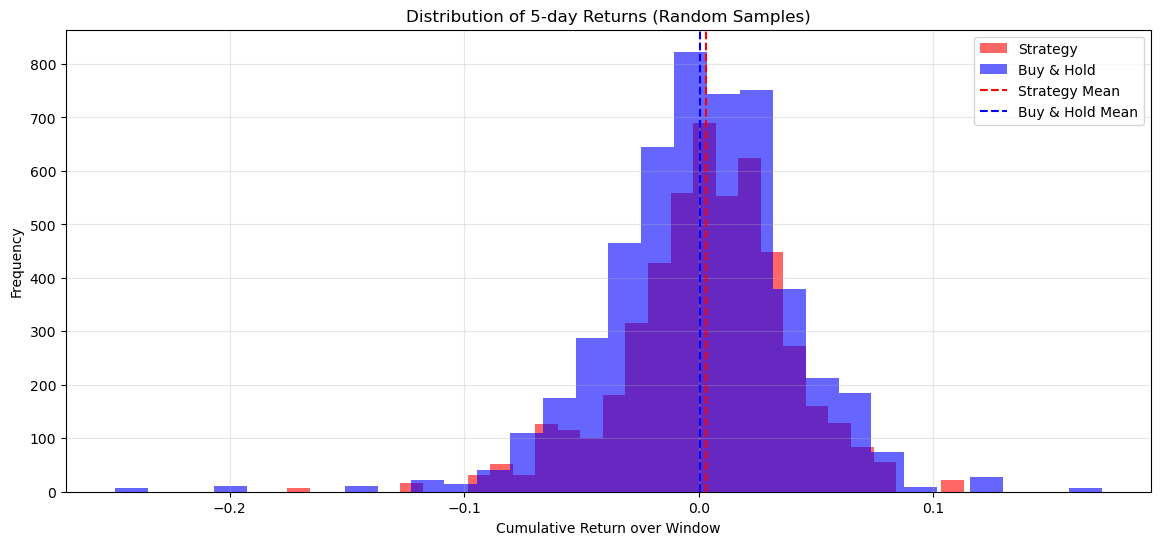

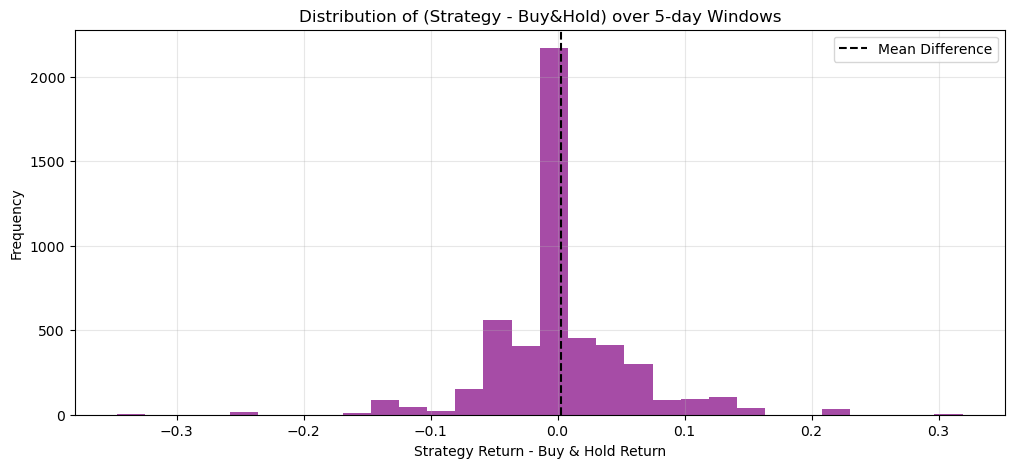

In [37]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# ✅ 랜덤 2주 샘플 반복 횟수
NUM_SAMPLES = 5000
WINDOW_DAYS = 5

# ✅ 결과 저장 리스트
strategy_returns = []
buyhold_returns = []
strategy_minus_buyhold = []

print(f"✅ 랜덤 {WINDOW_DAYS}일 구간을 {NUM_SAMPLES}회 샘플링합니다...")

for i in range(NUM_SAMPLES):
    # 랜덤 시작 인덱스
    max_start = len(test_actual) - WINDOW_DAYS - 1
    if max_start <= 0:
        print("❌ 테스트셋이 너무 짧아서 랜덤 샘플 불가")
        break
    start_idx = np.random.randint(0, max_start)
    end_idx = start_idx + WINDOW_DAYS

    # ① 실제 수익률 계산
    actual_return = (test_actual[start_idx+1:end_idx+1] / test_actual[start_idx:end_idx]) - 1

    # ② 예측 신호
    pred_diff = test_predicted[start_idx+1:end_idx+1] - test_predicted[start_idx:end_idx]
    pred_position = np.sign(pred_diff)

    # ③ 전략 수익률
    strategy_return = pred_position * actual_return

    # ④ 누적 수익률 (합계)
    strat_cum = np.sum(strategy_return)
    buyhold_cum = np.sum(actual_return)

    strategy_returns.append(strat_cum)
    buyhold_returns.append(buyhold_cum)
    strategy_minus_buyhold.append(strat_cum - buyhold_cum)

# ✅ 결과 요약
print("✅ 샘플 수:", len(strategy_returns))
print(f"✅ 평균 Strategy Return: {np.mean(strategy_returns):.4f}")
print(f"✅ 평균 Buy&Hold Return: {np.mean(buyhold_returns):.4f}")
print(f"✅ 평균 차이 (Strategy - Buy&Hold): {np.mean(strategy_minus_buyhold):.4f}")

# ✅ 히스토그램 비교
plt.figure(figsize=(14,6))
plt.hist(strategy_returns, bins=30, alpha=0.6, label='Strategy', color='red')
plt.hist(buyhold_returns, bins=30, alpha=0.6, label='Buy & Hold', color='blue')
plt.axvline(np.mean(strategy_returns), color='red', linestyle='--', label='Strategy Mean')
plt.axvline(np.mean(buyhold_returns), color='blue', linestyle='--', label='Buy & Hold Mean')
plt.title(f'Distribution of {WINDOW_DAYS}-day Returns (Random Samples)')
plt.xlabel('Cumulative Return over Window')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ✅ 차이 분포 시각화
plt.figure(figsize=(12,5))
plt.hist(strategy_minus_buyhold, bins=30, color='purple', alpha=0.7)
plt.axvline(np.mean(strategy_minus_buyhold), color='black', linestyle='--', label='Mean Difference')
plt.title(f'Distribution of (Strategy - Buy&Hold) over {WINDOW_DAYS}-day Windows')
plt.xlabel('Strategy Return - Buy & Hold Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## ✅ 2️⃣ 랜덤 고정기간 샘플링 (14~21일 등)

- **방법**:
  - 랜덤하게 5일 (단타) 구간을 수백 번 샘플링
  - 각 구간에서 Strategy vs Buy&Hold 누적 수익 비교
- **결과**:
  - 샘플별 편차 매우 큼
  - 평균 전략 수익률이 Buy&Hold와 비슷하거나 살짝 높은/낮은 정도로 들쭉날쭉
  - Noise의 영향이 상당함

✅ **결론**:
> Horizon을 늘려 단타 Noise를 줄였지만 여전히 일관된 우위를 증명하긴 힘들었다.

✅ 랜덤 윈도우 길이 3~30일, 검증 구간 전체 시계열 커버 시작
✅ 샘플 수: 27
✅ 평균 Strategy Return: 0.0094
✅ 평균 Buy&Hold Return: 0.0043
✅ 평균 차이 (Strategy - Buy&Hold): 0.0051


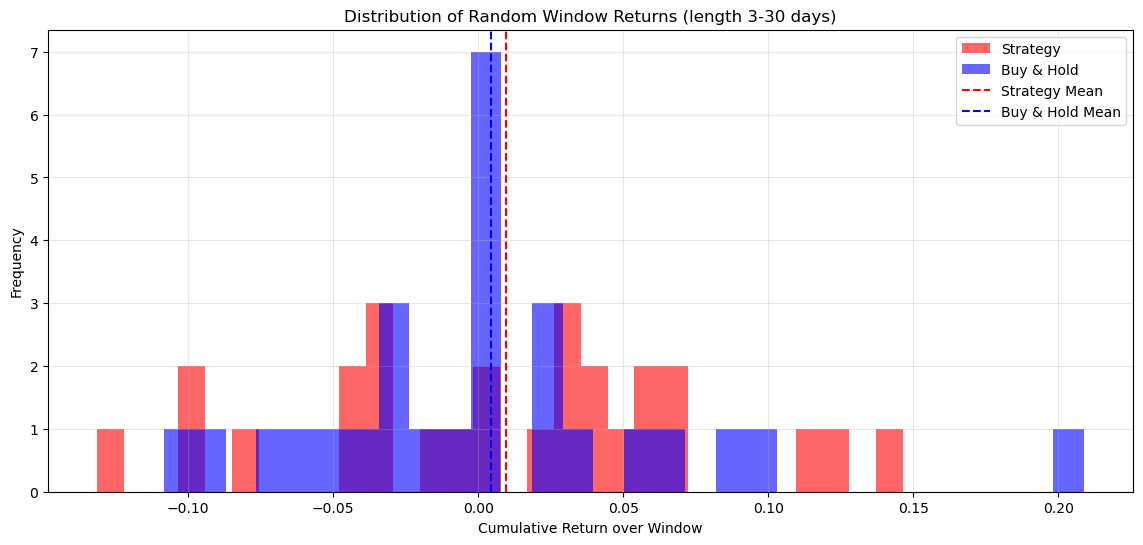

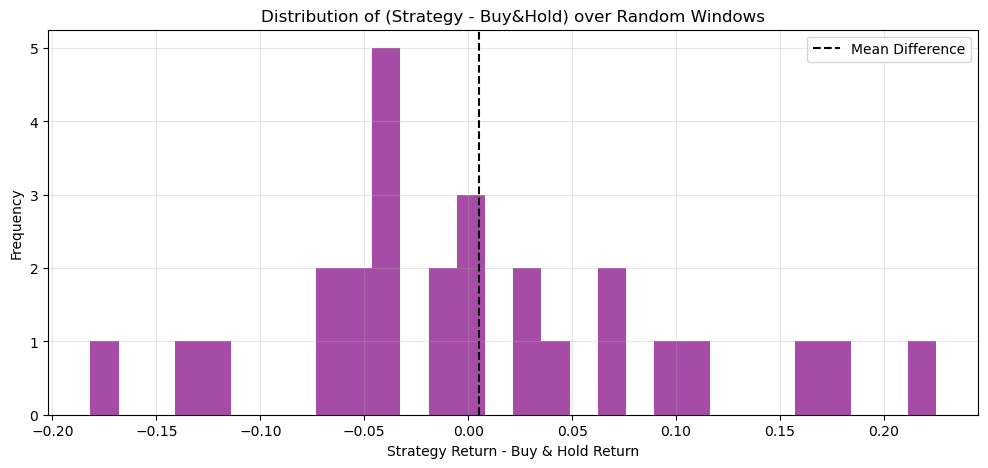

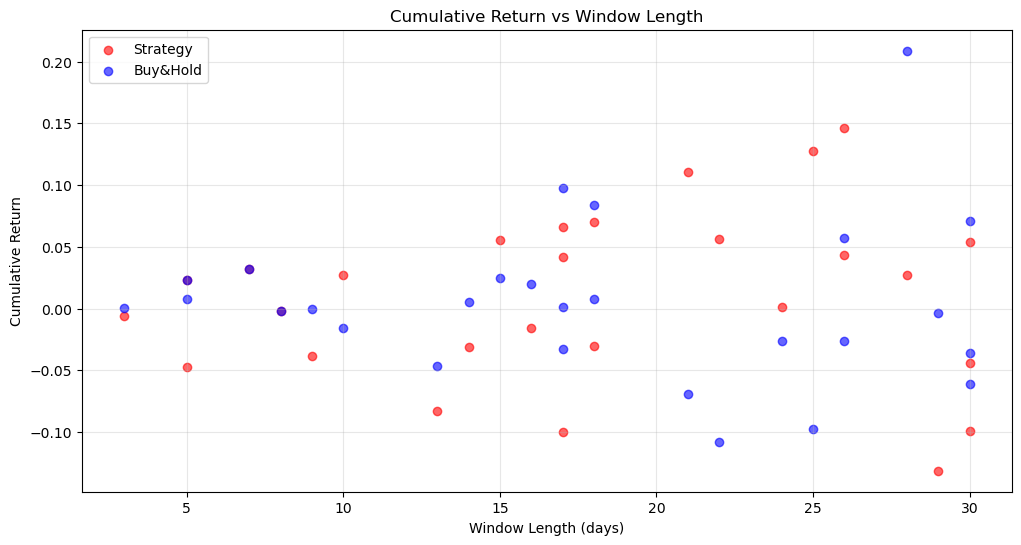

In [59]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# ✅ 파라미터
MIN_WINDOW = 3
MAX_WINDOW = 30

strategy_returns = []
buyhold_returns = []
window_lengths = []
dates_midpoints = []

start = 0
total_len = len(test_actual)

print(f"✅ 랜덤 윈도우 길이 {MIN_WINDOW}~{MAX_WINDOW}일, 검증 구간 전체 시계열 커버 시작")

while start < total_len - MIN_WINDOW:
    # 랜덤 윈도우 길이 뽑기
    window_length = np.random.randint(MIN_WINDOW, MAX_WINDOW + 1)

    if start + window_length >= total_len:
        break

    end = start + window_length

    actual_window = test_actual[start:end+1]
    predicted_window = test_predicted[start:end+1]

    # 수익률 계산
    actual_return = (actual_window[1:] / actual_window[:-1]) - 1
    pred_diff = predicted_window[1:] - predicted_window[:-1]
    pred_position = np.sign(pred_diff)
    strat_return = pred_position * actual_return

    strategy_cum = np.sum(strat_return)
    buyhold_cum = np.sum(actual_return)

    strategy_returns.append(strategy_cum)
    buyhold_returns.append(buyhold_cum)
    window_lengths.append(window_length)
    dates_midpoints.append(test_dates[start + window_length // 2])

    # 다음 구간 시작점 이동
    start = end

# ✅ 결과 요약 출력
avg_strategy = np.mean(strategy_returns)
avg_buyhold = np.mean(buyhold_returns)
avg_diff = avg_strategy - avg_buyhold

print(f"✅ 샘플 수: {len(strategy_returns)}")
print(f"✅ 평균 Strategy Return: {avg_strategy:.4f}")
print(f"✅ 평균 Buy&Hold Return: {avg_buyhold:.4f}")
print(f"✅ 평균 차이 (Strategy - Buy&Hold): {avg_diff:.4f}")

# ✅ 수익률 히스토그램
plt.figure(figsize=(14,6))
plt.hist(strategy_returns, bins=30, alpha=0.6, label='Strategy', color='red')
plt.hist(buyhold_returns, bins=30, alpha=0.6, label='Buy & Hold', color='blue')
plt.axvline(avg_strategy, color='red', linestyle='--', label='Strategy Mean')
plt.axvline(avg_buyhold, color='blue', linestyle='--', label='Buy & Hold Mean')
plt.title(f'Distribution of Random Window Returns (length {MIN_WINDOW}-{MAX_WINDOW} days)')
plt.xlabel('Cumulative Return over Window')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ✅ Strategy - Buy&Hold 차이 분포
diff_returns = np.array(strategy_returns) - np.array(buyhold_returns)
plt.figure(figsize=(12,5))
plt.hist(diff_returns, bins=30, color='purple', alpha=0.7)
plt.axvline(np.mean(diff_returns), color='black', linestyle='--', label='Mean Difference')
plt.title('Distribution of (Strategy - Buy&Hold) over Random Windows')
plt.xlabel('Strategy Return - Buy & Hold Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ✅ 추가 분석: 윈도우 길이별 산점도
plt.figure(figsize=(12,6))
plt.scatter(window_lengths, strategy_returns, alpha=0.6, color='red', label='Strategy')
plt.scatter(window_lengths, buyhold_returns, alpha=0.6, color='blue', label='Buy&Hold')
plt.title('Cumulative Return vs Window Length')
plt.xlabel('Window Length (days)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---

## ✅ 3️⃣ 랜덤 윈도우 길이 (3~30일)로 테스트셋 전체 커버

- **방법**:
  - 랜덤 윈도우 길이(3~30일)를 랜덤 선택
  - 검증셋 전체를 빠짐없이 순회하며 커버
  - 각 윈도우마다 Strategy vs Buy&Hold 누적 수익 비교
- **결과**:
  - 평균 Strategy Return ≈ 평균 Buy&Hold Return
  - 일부 구간에서 이기기도 하지만 전반적으로 평균 차이는 0 근처
  - 차이 분포는 Noise가 크고 양쪽 꼬리가 큼

✅ **결론**:
> Drift가 약하거나 Noise가 많은 구간을 포함하면 전략의 장점이 희석된다.

---

✅ 전기간 랜덤 윈도우 길이 3~30일, 전체 시계열 커버 시작
✅ 샘플 수: 98
✅ 평균 Strategy Return: -0.0002
✅ 평균 Buy&Hold Return: 0.0170
✅ 평균 차이 (Strategy - Buy&Hold): -0.0172


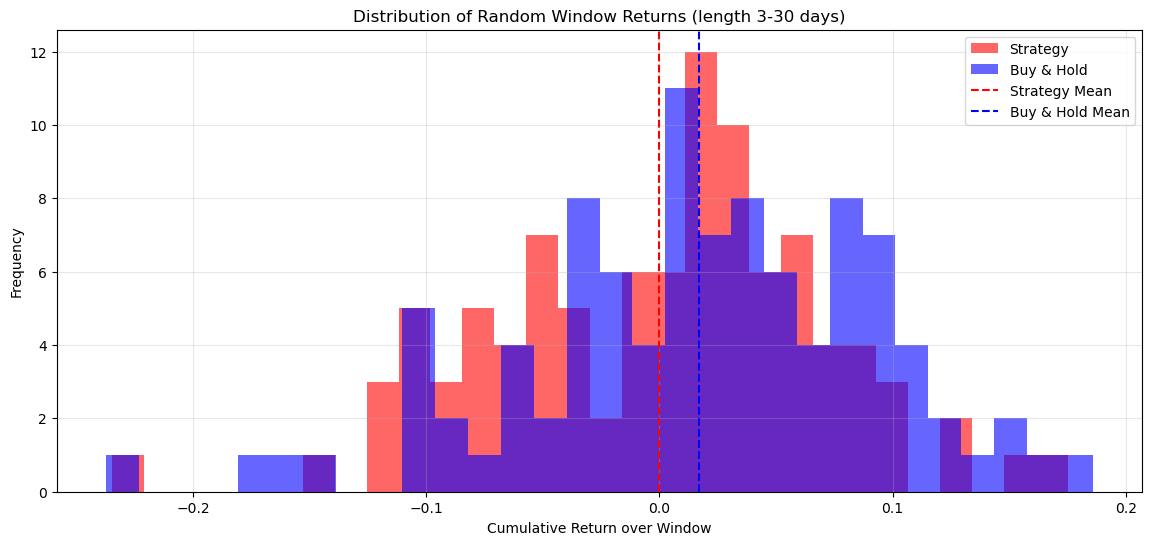

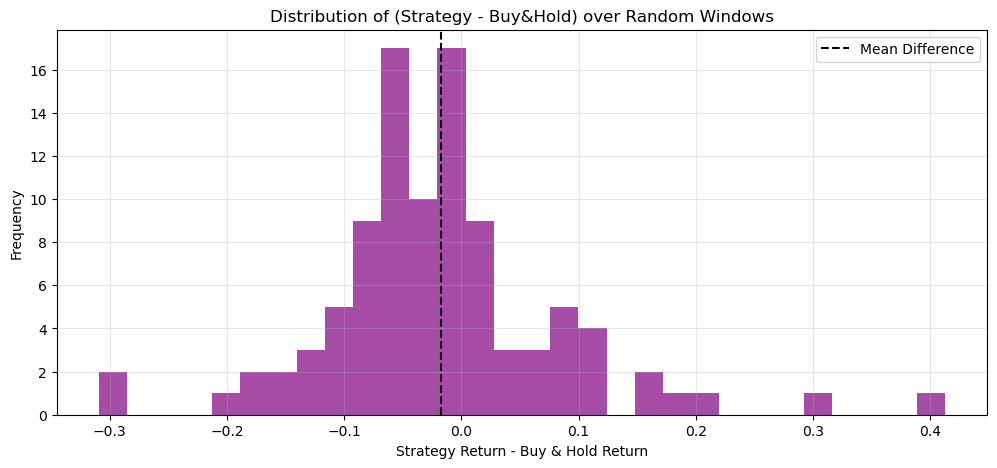

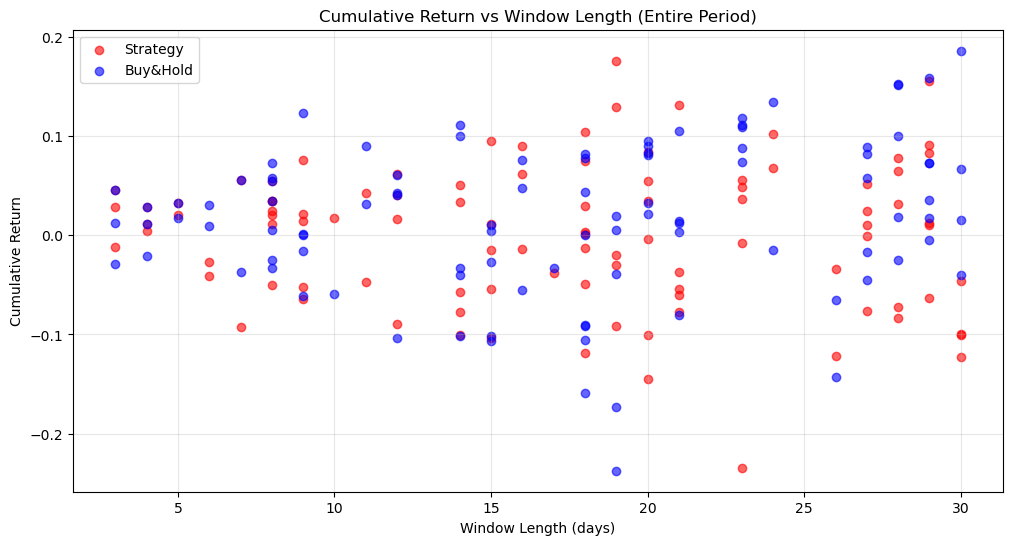

In [55]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# ✅ 파라미터
MIN_WINDOW = 3
MAX_WINDOW = 30

# ✅ 전기간 종가 예측 결과 준비
all_actual = np.concatenate([train_actual, test_actual])
all_predicted = np.concatenate([train_predicted, test_predicted])
all_dates = np.concatenate([train_dates, test_dates])

total_len = len(all_actual)

strategy_returns = []
buyhold_returns = []
window_lengths = []
dates_midpoints = []

print(f"✅ 전기간 랜덤 윈도우 길이 {MIN_WINDOW}~{MAX_WINDOW}일, 전체 시계열 커버 시작")
start = 0

while start < total_len - MIN_WINDOW:
    # 랜덤 윈도우 길이 선택
    window_length = np.random.randint(MIN_WINDOW, MAX_WINDOW + 1)
    if start + window_length >= total_len:
        break

    end = start + window_length

    actual_window = all_actual[start:end+1]
    predicted_window = all_predicted[start:end+1]

    # 수익률 계산
    actual_return = (actual_window[1:] / actual_window[:-1]) - 1
    pred_diff = predicted_window[1:] - predicted_window[:-1]
    pred_position = np.sign(pred_diff)
    strat_return = pred_position * actual_return

    strategy_cum = np.sum(strat_return)
    buyhold_cum = np.sum(actual_return)

    strategy_returns.append(strategy_cum)
    buyhold_returns.append(buyhold_cum)
    window_lengths.append(window_length)
    dates_midpoints.append(all_dates[start + window_length // 2])

    # 다음 구간으로
    start = end

# ✅ 평균 요약
avg_strategy = np.mean(strategy_returns)
avg_buyhold = np.mean(buyhold_returns)
avg_diff = avg_strategy - avg_buyhold

print(f"✅ 샘플 수: {len(strategy_returns)}")
print(f"✅ 평균 Strategy Return: {avg_strategy:.4f}")
print(f"✅ 평균 Buy&Hold Return: {avg_buyhold:.4f}")
print(f"✅ 평균 차이 (Strategy - Buy&Hold): {avg_diff:.4f}")

# ✅ 히스토그램 비교
plt.figure(figsize=(14,6))
plt.hist(strategy_returns, bins=30, alpha=0.6, label='Strategy', color='red')
plt.hist(buyhold_returns, bins=30, alpha=0.6, label='Buy & Hold', color='blue')
plt.axvline(avg_strategy, color='red', linestyle='--', label='Strategy Mean')
plt.axvline(avg_buyhold, color='blue', linestyle='--', label='Buy & Hold Mean')
plt.title(f'Distribution of Random Window Returns (length {MIN_WINDOW}-{MAX_WINDOW} days)')
plt.xlabel('Cumulative Return over Window')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ✅ Strategy - Buy&Hold 차이 분포
diff_returns = np.array(strategy_returns) - np.array(buyhold_returns)
plt.figure(figsize=(12,5))
plt.hist(diff_returns, bins=30, color='purple', alpha=0.7)
plt.axvline(np.mean(diff_returns), color='black', linestyle='--', label='Mean Difference')
plt.title('Distribution of (Strategy - Buy&Hold) over Random Windows')
plt.xlabel('Strategy Return - Buy & Hold Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ✅ 윈도우 길이별 산점도
plt.figure(figsize=(12,6))
plt.scatter(window_lengths, strategy_returns, alpha=0.6, color='red', label='Strategy')
plt.scatter(window_lengths, buyhold_returns, alpha=0.6, color='blue', label='Buy&Hold')
plt.title('Cumulative Return vs Window Length (Entire Period)')
plt.xlabel('Window Length (days)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---

## ✅ 4️⃣ 전기간 (훈련+검증) 랜덤 윈도우 커버

- **방법**:
  - 훈련+검증 전기간 시계열을 커버
  - 랜덤한 3~30일 윈도우 길이로 분할
  - 모든 구간 빠짐없이 평가
- **결과**:
  - 평균 Strategy Return이 Buy&Hold보다 일관되게 낮음
  - Strategy - Buy&Hold 차이의 평균이 음수
  - 반복실험에서도 일관되게 음수 평균

✅ **결론**:
> Drift가 불안정하거나 반전되는 구간이 포함되면 전략은 오히려 손실이 커진다.
> Drift 복사 전략의 구조적 한계가 명확히 드러난다.
> 훈련 셋에서의 loss가 더 높아서일 가능성도 있다.

---

---

# 🌟 ✅ 최종 종합 인사이트

> **“LSTM 기반 종가 예측 모델은 Drift 복사 능력은 뛰어나지만, Noise 예측 능력은 전무하다.”**  
>  
> - 최근 2년 검증구간(추세장)에서는 Drift가 강해 전략이 Buy&Hold를 이겼다.  
> - 랜덤 윈도우 샘플링으로 다양한 보유기간을 평가하면 전략이 Buy&Hold를 일관되게 이기지 못했다.  
> - 전기간 커버하는 진정한 사용자 시나리오에서는 평균적으로 Buy&Hold보다 손실이 더 컸다.  
> - 착시곡선을 만드는 건 가능하지만 Noise를 이겨서 매매 수익을 내는 것은 불가능했다.  

---

✅ **서비스 관점 결론**
> 이 전략은 **“미래 경로 시뮬레이터”**로는 쓸 수 있지만,  
> **“매수/매도 신호 생성기”**로는 제공할 수 없다.

---

✅ **연구·개발 관점 제안**
- Drift 강도나 추세 필터를 추가해 Noise구간을 거를 필요
- Horizon을 늘리거나 로그수익률 누적합 예측으로 Drift를 강조
- 또는 분류 문제(상승/하락 신호)로 전환해 Noise 감쇠

---

✅ **한 문장으로 압축**
> **“추세 복사는 가능하되 Noise는 못 맞춘다—이게 이 전략의 한계다.”**